In [45]:
!pip install emoji
!pip install contractions

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 608.4/608.4 kB 8.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 345.1/345.1 kB 6.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 114.9/114.9 kB 8.9 MB/s eta 0:00:00


In [81]:
import io
import requests
from google.colab import drive
from google.colab import files
from os.path import exists
from os import environ, system

In [3]:
uploaded = files.upload()

Saving Fake.csv to Fake.csv
Saving True.csv to True.csv


In [130]:
# Import necessary libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import re
import nltk
import contractions
from nltk.corpus import stopwords
from nltk.tokenize import word_tokenize
from nltk.stem import WordNetLemmatizer
from collections import Counter
import warnings
warnings.filterwarnings('ignore')

In [131]:
nltk.download('punkt')
nltk.download('stopwords')
nltk.download('wordnet')
nltk.download('punkt_tab')
nltk.download('wordnet')
nltk.download('omw-1.4')

[nltk_data] Downloading package punkt to /root/nltk_data...
[nltk_data]   Package punkt is already up-to-date!
[nltk_data] Downloading package stopwords to /root/nltk_data...
[nltk_data]   Package stopwords is already up-to-date!
[nltk_data] Downloading package wordnet to /root/nltk_data...
[nltk_data]   Package wordnet is already up-to-date!
[nltk_data] Downloading package punkt_tab to /root/nltk_data...
[nltk_data]   Package punkt_tab is already up-to-date!
[nltk_data] Downloading package wordnet to /root/nltk_data...
[nltk_data]   Package wordnet is already up-to-date!
[nltk_data] Downloading package omw-1.4 to /root/nltk_data...
[nltk_data]   Package omw-1.4 is already up-to-date!


True

In [132]:
# Load the datasets
fake_df = pd.read_csv('Fake.csv')
true_df = pd.read_csv('True.csv')

# Add label column: 0 for Fake, 1 for True
fake_df['label'] = 0
true_df['label'] = 1

# Merge the two datasets in to a dataframe
df = pd.concat([fake_df, true_df], ignore_index=True)

# Shuffle the dataset to avoid any ordering bias
df = df.sample(frac=1, random_state=42).reset_index(drop=True)

# showing basic information
print("Dataset Shape:", df.shape)
print("Columns:", df.columns.tolist())

Dataset Shape: (44898, 5)
Columns: ['title', 'text', 'subject', 'date', 'label']


In [133]:
df.head()

,title,text,subject,date,label
0,Ben Stein Calls Out 9th Circuit Court: Committ...,"21st Century Wire says Ben Stein, reputable pr...",US_News,"February 13, 2017",0
1,Trump drops Steve Bannon from National Securit...,WASHINGTON (Reuters) - U.S. President Donald T...,politicsNews,"April 5, 2017",1
2,Puerto Rico expects U.S. to lift Jones Act shi...,(Reuters) - Puerto Rico Governor Ricardo Rosse...,politicsNews,"September 27, 2017",1
3,OOPS: Trump Just Accidentally Confirmed He Le...,"On Monday, Donald Trump once again embarrassed...",News,"May 22, 2017",0
4,Donald Trump heads for Scotland to reopen a go...,"GLASGOW, Scotland (Reuters) - Most U.S. presid...",politicsNews,"June 24, 2016",1


In [134]:
# Basic information
print("=== Dataset Information ===")
print(df.info())

print("\n=== Descriptive Statistics ===")
print(df.describe(include='all'))

# Class distribution
print("\n=== Class Distribution ===")
class_dist = df['label'].value_counts()
print(class_dist)
print("\nPercentage:")
print(df['label'].value_counts(normalize=True) * 100)

# Text length statistics
df['text_length'] = df['text'].str.len()
df['title_length'] = df['title'].str.len()
df['word_count'] = df['text'].str.split().str.len()

print("\n=== Text Length Statistics ===")
print(df.groupby('label')[['text_length', 'title_length', 'word_count']].describe())

=== Dataset Information ===
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 44898 entries, 0 to 44897
Data columns (total 5 columns):
 #   Column   Non-Null Count  Dtype 
---  ------   --------------  ----- 
 0   title    44898 non-null  object
 1   text     44898 non-null  object
 2   subject  44898 non-null  object
 3   date     44898 non-null  object
 4   label    44898 non-null  int64 
dtypes: int64(1), object(4)
memory usage: 1.7+ MB
None

=== Descriptive Statistics ===
                                                    title   text  \
count                                               44898  44898   
unique                                              38729  38646   
top     Factbox: Trump fills top jobs for his administ...          
freq                                                   14    627   
mean                                                  NaN    NaN   
std                                                   NaN    NaN   
min                                       

**Visualization**

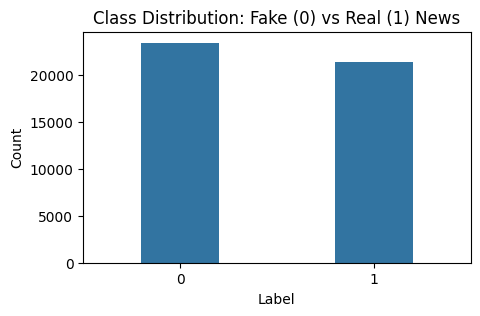

In [20]:
# 1. Class Distribution
plt.figure(figsize=(5, 3))
sns.countplot(data=df, x='label', width=0.4)
plt.title('Class Distribution: Fake (0) vs Real (1) News')
plt.xlabel('Label')
plt.ylabel('Count')
plt.show()

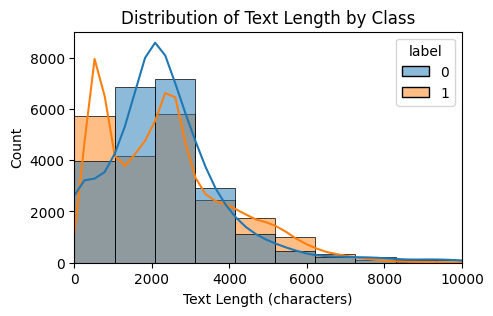

In [40]:
# 2. Text Length Distribution by Class
plt.figure(figsize=(5, 3))
sns.histplot(data=df, x='text_length', hue='label', kde=True, bins=50)
plt.title('Distribution of Text Length by Class')
plt.xlabel('Text Length (characters)')
plt.xlim(0, 10000)  # Limit for better visibility
plt.show()

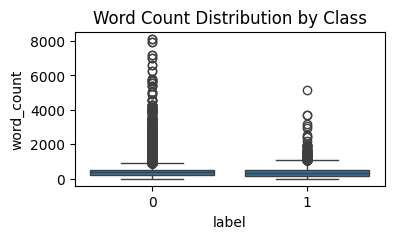

In [42]:
# 3. Average Word Count by Class
plt.figure(figsize=(4, 2))
sns.boxplot(data=df, x='label', y='word_count')
plt.title('Word Count Distribution by Class')
plt.show()

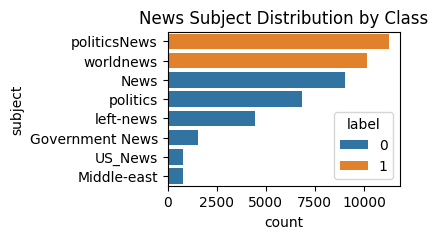

In [44]:
# 4. Subject Distribution
plt.figure(figsize=(3, 2))
sns.countplot(data=df, y='subject', hue='label', order=df['subject'].value_counts().index)
plt.title('News Subject Distribution by Class')
plt.show()

In [31]:
# 5. Most Common Words (after simple cleaning) - Word Cloud or Bar Chart
def get_top_words(text_series, n=20):
    all_text = ' '.join(text_series.astype(str).str.lower())
    words = re.findall(r'\b\w+\b', all_text)
    stop_words = set(stopwords.words('english'))
    words = [w for w in words if w not in stop_words and len(w) > 2]
    return Counter(words).most_common(n)

fake_top = get_top_words(df[df['label'] == 0]['text'])
real_top = get_top_words(df[df['label'] == 1]['text'])

print("Top 10 words in Fake News:", fake_top[:10])
print("Top 10 words in Real News:", real_top[:10])

Top 10 words in Fake News: [('trump', 79300), ('said', 33763), ('president', 27715), ('people', 26570), ('one', 24531), ('would', 23562), ('clinton', 19173), ('obama', 18797), ('like', 18097), ('donald', 17671)]
Top 10 words in Real News: [('said', 99062), ('trump', 54700), ('would', 31605), ('reuters', 28976), ('president', 28177), ('state', 21025), ('government', 18846), ('new', 16917), ('states', 16652), ('house', 16640)]


**Preprocessing**

In [135]:
# Initialize tools
stop_words = set(stopwords.words('english'))
lemmatizer = WordNetLemmatizer()
# getting all kind of characters
def remove_emoji_char(text):
    emoji_pattern_char = re.compile("["
        u"\U0001F600-\U0001F64F"
        u"\U0001F300-\U0001F5FF"
        u"\U0001F680-\U0001F6FF"
        u"\U0001F1E0-\U0001F1FF"
        u"\U00002702-\U000027B0"
        u"\U000024C2-\U0001F251"
        "]+", flags=re.UNICODE)
    return emoji_pattern_char.sub(r'', text)

def preprocess_text(text):
    if not isinstance(text, str):
        return ""

    # handling Lowercasing, emojis
    text = text.lower()
    text = remove_emoji_char(text)
    text = contractions.fix(text)
    # Remove punctuation, numbers, and special characters, link, white spaces
    text = re.sub(r'[^a-z\s]', ' ', text)
    text = re.sub(r'http\S+|www\S+|https\S+|@\w+|#\w+', '', text)
    text = re.sub(r'\s+', ' ', text).strip()

    # Tokenization, Remove stopwords, Lemmatization
    tokens = word_tokenize(text)
    tokens = [word for word in tokens if word not in stop_words and len(word) > 2]
    tokens = [lemmatizer.lemmatize(word) for word in tokens]
    # Join back to string
    return ' '.join(tokens)

# Apply preprocessing to both title and text
df['clean_text'] = df['text'].apply(preprocess_text)
# Also preprocess title and combine
df['clean_title'] = df['title'].astype(str).apply(preprocess_text)
df['combined_text'] = df['clean_title'] + " " + df['clean_text']

sample_idx = 0
print(df['text'].iloc[sample_idx][:300])
print("\nCleaned Text:")
print(df['clean_text'].iloc[sample_idx][:300])

21st Century Wire says Ben Stein, reputable professor from, Pepperdine University (also of some Hollywood fame appearing in TV shows and films such as Ferris Bueller s Day Off) made some provocative statements on Judge Jeanine Pirro s show recently. While discussing the halt that was imposed on Pres

Cleaned Text:
century wire say ben stein reputable professor pepperdine university also hollywood fame appearing show film ferris bueller day made provocative statement judge jeanine pirro show recently discussing halt imposed president trump executive order travel stein referred judgement circuit court washingto


In [124]:
df.drop(['text_length', 'title_length', 'word_count'], axis=1, inplace=True)

In [125]:
df.head()

,title,text,subject,date,label,clean_text,clean_title,combined_text
0,Ben Stein Calls Out 9th Circuit Court: Committ...,"21st Century Wire says Ben Stein, reputable pr...",US_News,"February 13, 2017",0,century wire say ben stein reputable professor...,ben stein call circuit court committed coup ta...,ben stein call circuit court committed coup ta...
1,Trump drops Steve Bannon from National Securit...,WASHINGTON (Reuters) - U.S. President Donald T...,politicsNews,"April 5, 2017",1,washington reuters president donald trump remo...,trump drop steve bannon national security council,trump drop steve bannon national security coun...
2,Puerto Rico expects U.S. to lift Jones Act shi...,(Reuters) - Puerto Rico Governor Ricardo Rosse...,politicsNews,"September 27, 2017",1,reuters puerto rico governor ricardo rossello ...,puerto rico expects lift jones act shipping re...,puerto rico expects lift jones act shipping re...
3,OOPS: Trump Just Accidentally Confirmed He Le...,"On Monday, Donald Trump once again embarrassed...",News,"May 22, 2017",0,monday donald trump embarrassed country accide...,oops trump accidentally confirmed leaked israe...,oops trump accidentally confirmed leaked israe...
4,Donald Trump heads for Scotland to reopen a go...,"GLASGOW, Scotland (Reuters) - Most U.S. presid...",politicsNews,"June 24, 2016",1,glasgow scotland reuters presidential candidat...,donald trump head scotland reopen golf resort,donald trump head scotland reopen golf resort ...


In [76]:
df.to_csv("Fake-true-news-cleaned-combined.csv", index=False)

**TF-IDF Technic**

In [101]:
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.model_selection import train_test_split

# Extract features and target
X = df['combined_text']          # or could be clean_text column
y = df['label']                  # 0 = Fake, 1 = Real

# TF-IDF Vectorization
tfidf = TfidfVectorizer(
    max_features=5000,      # Limit to 5000 important features to avoid overfitting
    min_df=5,               # Words that appear in at least 5 documents
    max_df=0.85,            # Remove words that are in more than 85% of documents
    ngram_range=(1, 2),     # Using unigrams and bigrams to capture meaningful phrases
    stop_words='english')
X_tfidf = tfidf.fit_transform(X)

print("TF-IDF Feature Matrix Shape:", X_tfidf.shape)
print("Number of features:", X_tfidf.shape[1])
# Convert to DataFrame (optional, for inspection)
feature_names = tfidf.get_feature_names_out()
print("\nSample Features:", feature_names[:20])

TF-IDF Feature Matrix Shape: (44898, 5000)
Number of features: 5000

Sample Features: ['abadi' 'abandon' 'abandoned' 'abbas' 'abc' 'abc news' 'abdullah' 'abe'
 'abedin' 'ability' 'able' 'abortion' 'abroad' 'absence' 'absolute'
 'absolutely' 'abu' 'abuse' 'academic' 'accept']


**pop() method** for Extracting the target classification variable (fake or real news)

In [63]:
y = df.pop('label')   # This function removes the label column and assigns it to y.

# Now df no longer has a label column
print("Label extracted using pop(). Remaining columns:", df.columns.tolist())

Label extracted using pop(). Remaining columns: ['title', 'text', 'subject', 'date', 'clean_text', 'clean_title', 'combined_text']


**Decision tree classifier**

In [127]:
from sklearn.model_selection import train_test_split
from sklearn.tree import DecisionTreeClassifier
from sklearn.metrics import (accuracy_score, precision_score, recall_score,
                             f1_score, confusion_matrix, classification_report)
from sklearn.feature_extraction.text import TfidfVectorizer

X = df['combined_text']
y = df['label']
# TF-IDF Vectorization
tfidf = TfidfVectorizer(max_features=5000, ngram_range=(1, 2), min_df=5, max_df=0.85)
X_tfidf = tfidf.fit_transform(X)
print("Shape of TF-IDF matrix:", X_tfidf.shape)

# split and test
X_train, X_test, y_train, y_test = train_test_split(X_tfidf, y, test_size=0.20,
    random_state=42, stratify=y)
print("Training set shape:", X_train.shape)
print("Testing set shape: ", X_test.shape)
print("Class distribution in train:", y_train.value_counts(normalize=True).round(3))
print("Class distribution in test: ", y_test.value_counts(normalize=True).round(3))

# training the model
dt_model = DecisionTreeClassifier(criterion='gini', max_depth=15,
    min_samples_split=5, min_samples_leaf=2, random_state=42)

dt_model.fit(X_train, y_train)

Shape of TF-IDF matrix: (44898, 5000)
Training set shape: (35918, 5000)
Testing set shape:  (8980, 5000)
Class distribution in train: label
0    0.523
1    0.477
Name: proportion, dtype: float64
Class distribution in test:  label
0    0.523
1    0.477
Name: proportion, dtype: float64


DecisionTreeClassifier(max_depth=15, min_samples_leaf=2, min_samples_split=5,
                       random_state=42)

In [102]:
df.columns

Index(['title', 'text', 'subject', 'date', 'label', 'clean_text',
       'clean_title', 'combined_text'],
      dtype='object')

**Evaluation**

Accuracy    : 0.9968 (99.68%)
Precision   : 0.9977
Recall      : 0.9956
F1-Score    : 0.9966
              precision    recall  f1-score   support

    Fake (0)       1.00      1.00      1.00      4696
    Real (1)       1.00      1.00      1.00      4284

    accuracy                           1.00      8980
   macro avg       1.00      1.00      1.00      8980
weighted avg       1.00      1.00      1.00      8980



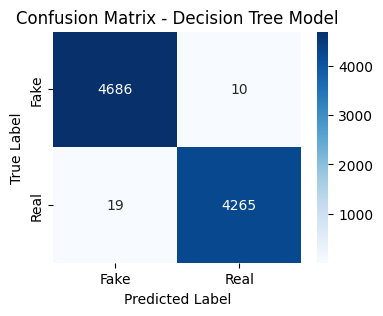

In [128]:
y_pred = dt_model.predict(X_test)
# Metrics
accuracy = accuracy_score(y_test, y_pred)
precision = precision_score(y_test, y_pred)
recall = recall_score(y_test, y_pred)
f1 = f1_score(y_test, y_pred)

print(f"Accuracy    : {accuracy:.4f} ({accuracy*100:.2f}%)")
print(f"Precision   : {precision:.4f}")
print(f"Recall      : {recall:.4f}")
print(f"F1-Score    : {f1:.4f}")

# Classification Report
print(classification_report(y_test, y_pred, target_names=['Fake (0)', 'Real (1)']))

# Confusion Matrix
cm = confusion_matrix(y_test, y_pred)
plt.figure(figsize=(4, 3))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=['Fake', 'Real'],
            yticklabels=['Fake', 'Real'])
plt.title('Confusion Matrix - Decision Tree Model')
plt.xlabel('Predicted Label')
plt.ylabel('True Label')
plt.show()

**Random Forest Classification** <p></p>
for this part after preprocessing will be done independently


In [136]:
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import (accuracy_score, precision_score, recall_score,
                             f1_score, confusion_matrix, classification_report)
# (Pipeline)
df['combined_text'] = df['title'].astype(str) + " " + df['text'].astype(str)
# creating object
stop_words = set(stopwords.words('english'))
lemmatizer = WordNetLemmatizer()

# TF-IDF
tfidf = TfidfVectorizer(max_features=8000, ngram_range=(1, 2),
    min_df=5, max_df=0.85, stop_words='english')

X = tfidf.fit_transform(df['clean_text'])
y = df['label']
print(f"TF-IDF Feature Matrix Shape: {X.shape}")

# Split
X_train, X_test, y_train, y_test = train_test_split(X, y,
    test_size=0.20, random_state=42, stratify=y)
print(f"Train set: {X_train.shape[0]} samples")
print(f"Test set : {X_test.shape[0]} samples")

# Random Forest
rf_model = RandomForestClassifier(n_estimators=200, max_depth=None,
    min_samples_split=2, min_samples_leaf=1, max_features='sqrt',
    bootstrap=True, random_state=42, n_jobs=-1)

rf_model.fit(X_train, y_train)

TF-IDF Feature Matrix Shape: (44898, 8000)
Train set: 35918 samples
Test set : 8980 samples


RandomForestClassifier(n_estimators=200, n_jobs=-1, random_state=42)

,Feature,Importance
5891,reuters,0.154682
6078,said,0.047802
7755,washington reuters,0.022936
3264,image,0.022425
2496,featured,0.016239


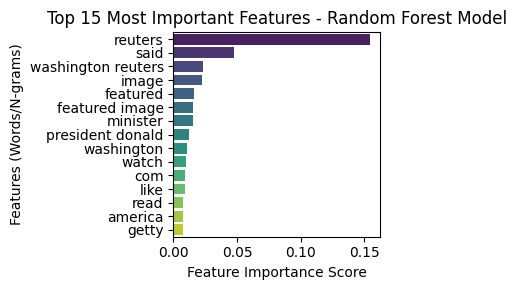

In [139]:
# feature extraction
feature_importances = rf_model.feature_importances_
feature_names = tfidf.get_feature_names_out()

# Importance ordering
importance_df = pd.DataFrame({'Feature': feature_names,'Importance': feature_importances})
importance_df = importance_df.sort_values('Importance', ascending=False)
display(importance_df.head(5))

# illustration
plt.figure(figsize=(4, 3))
sns.barplot(data=importance_df.head(15), x='Importance', y='Feature', palette='viridis')
plt.title('Top 15 Most Important Features - Random Forest Model')
plt.xlabel('Feature Importance Score')
plt.ylabel('Features (Words/N-grams)')
plt.tight_layout()
plt.show()

In [140]:
# Evaluation
y_pred_rf = rf_model.predict(X_test)

print("=== Random Forest Performance Metrics ===")
print(f"Accuracy    : {accuracy_score(y_test, y_pred_rf):.4f}")
print(f"Precision   : {precision_score(y_test, y_pred_rf):.4f}")
print(f"Recall      : {recall_score(y_test, y_pred_rf):.4f}")
print(f"F1-Score    : {f1_score(y_test, y_pred_rf):.4f}")

print(classification_report(y_test, y_pred_rf, target_names=['Fake (0)', 'Real (1)']))

=== Random Forest Performance Metrics ===
Accuracy    : 0.9976
Precision   : 0.9963
Recall      : 0.9986
F1-Score    : 0.9974
              precision    recall  f1-score   support

    Fake (0)       1.00      1.00      1.00      4696
    Real (1)       1.00      1.00      1.00      4284

    accuracy                           1.00      8980
   macro avg       1.00      1.00      1.00      8980
weighted avg       1.00      1.00      1.00      8980

